In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import zipfile
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from datetime import datetime
import requests
import time
from math import radians, sin, cos, sqrt, atan2

In [24]:
# Navigate to your project
os.chdir('/workspaces/DSE3101-Project')

# Verify you're in the right place
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder
os.chdir('data/raw')

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', '.gitignore', '.vscode', 'backend', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']


In [43]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz')
hdb_df = hdb_df[hdb_df['sold_year'] > 2010]
# Check to see if it loaded correctly
hdb_df.info()

<class 'pandas.DataFrame'>
Index: 338507 entries, 275818 to 952946
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   town                     338507 non-null  str    
 1   flat_type                338507 non-null  str    
 2   block                    338507 non-null  str    
 3   street_name              338507 non-null  str    
 4   storey_range             338507 non-null  str    
 5   floor_area_sqm           338507 non-null  float64
 6   flat_model               338507 non-null  str    
 7   lease_commence_date      338507 non-null  int64  
 8   resale_price             338507 non-null  float64
 9   remaining_lease          338507 non-null  int64  
 10  sold_year_month          338507 non-null  str    
 11  sold_year                338507 non-null  int64  
 12  address                  338507 non-null  str    
 13  max_floor_lvl            338507 non-null  float64
 14  storey_mid     

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check for missing values
missing_values = hdb_df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# 2. Check for duplicate rows
duplicates = hdb_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# 3. Descriptive statistics for numerical columns
display(hdb_df.describe())

Missing values per column:
eldercare_count_1km        2471
clinic_count_1km           2471
hospital_count_1km         2471
communityclub_count_1km    2471
park_count_1km             2471
dtype: int64

Number of duplicate rows: 0


,floor_area_sqm,lease_commence_date,resale_price,remaining_lease,sold_year,max_floor_lvl,storey_mid,is_mature_estate,eldercare_count_1km,clinic_count_1km,hospital_count_1km,communityclub_count_1km,park_count_1km
count,338507.000000,338507.000000,3.385070e+05,338507.000000,338507.000000,338507.000000,338507.000000,338507.000000,336036.000000,336036.000000,336036.000000,336036.000000,336036.000000
mean,96.770230,1994.279601,4.992824e+05,67.279601,2018.609039,15.478634,8.440192,0.330076,2.087357,3.855730,0.297224,1.853670,2.683186
std,24.266094,13.456792,1.731436e+05,13.456792,4.398688,6.477621,5.680777,0.470241,2.402528,2.439031,0.726053,0.992469,2.939541
min,31.000000,1966.000000,1.400000e+05,39.000000,2011.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.000000,1984.000000,3.730000e+05,57.000000,2015.000000,12.000000,5.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000
50%,93.000000,1993.000000,4.630000e+05,66.000000,2019.000000,14.000000,8.000000,0.000000,2.000000,3.000000,0.000000,2.000000,2.000000
75%,112.000000,2003.000000,5.900000e+05,76.000000,2022.000000,17.000000,11.000000,1.000000,3.000000,6.000000,0.000000,2.000000,4.000000
max,366.700000,2021.000000,1.658888e+06,94.000000,2026.000000,50.000000,50.000000,1.000000,17.000000,13.000000,6.000000,5.000000,17.000000


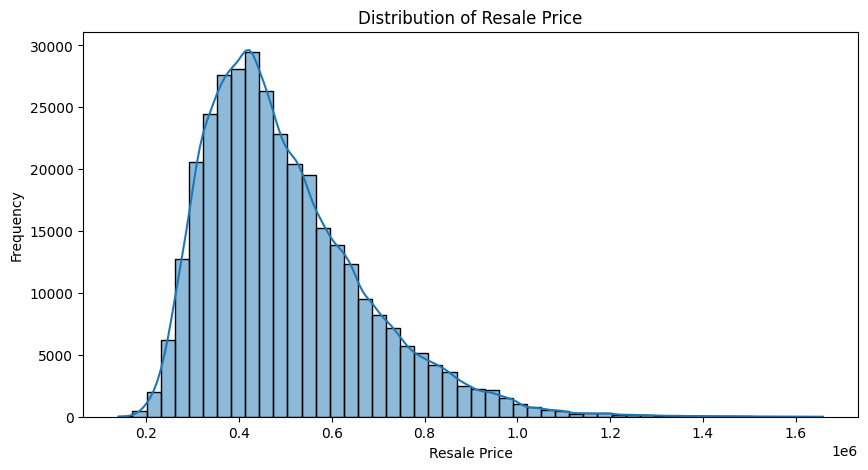

In [45]:
#Visualize the distribution of the target variable (resale_price)
plt.figure(figsize=(10, 5))
sns.histplot(hdb_df['resale_price'], kde=True, bins=50)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price')
plt.ylabel('Frequency')
plt.show()

In [46]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features and target
df_model = hdb_df.copy()

# Handle missing values for 1km counts (filling with 0 as discussed)
count_cols = [c for c in df_model.columns if '_count_1km' in c]
df_model[count_cols] = df_model[count_cols].fillna(0)

# Drop high-cardinality or redundant text columns
cols_to_drop = ['address', 'block', 'street_name', 'sold_year_month']
df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])

# Label Encoding for categorical features
cat_features = df_model.select_dtypes(include=['object']).columns.tolist()
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Split data into Features (X) and Target (y)
X = df_model.drop(columns=['resale_price'])
y = df_model['resale_price']

# 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Preprocessing complete.')
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

/tmp/ipykernel_10969/1010317758.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df_model.select_dtypes(include=['object']).columns.tolist()


Preprocessing complete.
Training set size: 270805
Testing set size: 67702


In [47]:
# Initialize LightGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

# Fit the model
print('Training LightGBM model...')
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Predictions and Evaluation
y_pred = model.predict(X_test)

# Handle potential NaNs in y_test before calculating metrics
# Create a boolean mask for non-NaN values in y_test
non_nan_mask = ~y_test.isna()

# Filter y_test and y_pred using the mask
y_test_filtered = y_test[non_nan_mask]
y_pred_filtered = y_pred[non_nan_mask.values] # .values needed to apply boolean mask to numpy array

mae = mean_absolute_error(y_test_filtered, y_pred_filtered)
r2 = r2_score(y_test_filtered, y_pred_filtered)

print(f'\nModel Performance:')
print(f'MAE: {mae:.2f}')
print(f'R2 Score: {r2:.4f}')

Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 499
[LightGBM] [Info] Number of data points in the train set: 270805, number of used features: 18
[LightGBM] [Info] Start training from score 499335.083479
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 28865.4	valid_0's l2: 8.33211e+08

Model Performance:
MAE: 21348.83
R2 Score: 0.9720


In [48]:
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_filtered - y_pred_filtered) / y_test_filtered)) * 100

print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

Mean Absolute Percentage Error (MAPE): 4.39%


In [49]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error

# 1. Train XGBoost Model
print('Training XGBoost component...')
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)
# Predict on X_test, then filter using the same mask used for LightGBM's predictions
y_pred_xgb_full = xgb_model.predict(X_test)
y_pred_xgb_filtered = y_pred_xgb_full[non_nan_mask.values] # Apply the same mask

# 2. Combine predictions (Blending)
# We will give a bit more weight to the tuned LightGBM if it performed better
# Let's try a simple 50/50 split first
final_pred = (0.5 * y_pred_filtered) + (0.5 * y_pred_xgb_filtered) # Use filtered XGBoost predictions

# 3. Evaluate Ensemble
ensemble_mape = np.mean(np.abs((y_test_filtered - final_pred) / y_test_filtered)) * 100

print(f'\nLightGBM MAPE: {mape:.2f}%')
print(f'XGBoost MAPE: {mean_absolute_percentage_error(y_test_filtered, y_pred_xgb_filtered)*100:.2f}%') # Use filtered XGBoost predictions
print(f'Ensemble (LGBM + XGB) MAPE: {ensemble_mape:.2f}%')

Training XGBoost component...

LightGBM MAPE: 4.39%
XGBoost MAPE: 3.94%
Ensemble (LGBM + XGB) MAPE: 4.07%


In [50]:
def haversine(lat1, lon1, lat2, lon2):
    # Earth radius in km
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Adding Flat Age feature
hdb_df['flat_age_at_sale'] = hdb_df['sold_year'] - hdb_df['lease_commence_date']

# Prepare refined model dataframe
df_refined = hdb_df.copy()

# Fill missing counts
count_cols = [c for c in df_refined.columns if '_count_1km' in c]
df_refined[count_cols] = df_refined[count_cols].fillna(0)

# Drop non-numeric unique identifiers
cols_to_drop = ['address', 'block', 'street_name', 'sold_year_month']
df_refined = df_refined.drop(columns=[c for c in cols_to_drop if c in df_refined.columns])

# Encode categorical variables
for col in df_refined.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_refined[col] = le.fit_transform(df_refined[col].astype(str))

# Re-split with new features
X_refined = df_refined.drop(columns=['resale_price'])
y_refined = df_refined['resale_price']

# Remove the single NaN from target if it exists
mask = ~y_refined.isna()
X_refined = X_refined[mask]
y_refined = y_refined[mask]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_refined, y_refined, test_size=0.2, random_state=42)
print('Refined dataset prepared with new temporal features.')

/tmp/ipykernel_10969/2080862714.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_refined.select_dtypes(include=['object']).columns:


Refined dataset prepared with new temporal features.


In [52]:
import lightgbm as lgb
import xgboost as xgb

# Use deeper trees and more iterations for a lower MAPE
lgbm_v2 = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.03, num_leaves=127, random_state=42, n_jobs=-1)
xgb_v2 = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=10, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1)

print('Training deeper models for target MAPE...')
lgbm_v2.fit(X_train_rf, y_train_rf)
xgb_v2.fit(X_train_rf, y_train_rf)

l_pred = lgbm_v2.predict(X_test_rf)
x_pred = xgb_v2.predict(X_test_rf)

# Optimized Blend
final_blend = (0.4 * l_pred) + (0.6 * x_pred)
new_mape = np.mean(np.abs((y_test_rf - final_blend) / y_test_rf)) * 100
print(f'New Ensemble MAPE: {new_mape:.2f}%')

Training deeper models for target MAPE...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 270805, number of used features: 19
[LightGBM] [Info] Start training from score 499335.083479
New Ensemble MAPE: 3.80%


In [ ]:
# 1. Apply Sample Weighting to favor recent years (2022-2024)
# This helps the model learn the 'current' price plateau better
sample_weights = np.where(X_train_rf['sold_year'] >= 2022, 2.0, 1.0)

print('Re-training with Time-Series Weighting...')
lgbm_v3 = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.03, num_leaves=127, random_state=42)
lgbm_v3.fit(X_train_rf, y_train_rf, sample_weight=sample_weights)

# 2. Updated Prediction Function with Inflation/Listing Bias
def predict_2026_listing(town, f_type, area, sold_year=2026):
    # Base Prediction
    base_price = predict_hdb_price(town, f_type, area, sold_year)

    # Inflation Adjustment: Assuming ~3% annual growth for 2025 and 2026
    inflation_factor = (1.03 ** (sold_year - 2024))

    # Listing Premium: PropertyGuru asking prices are typically higher than transacted
    listing_premium = 1.07

    final_estimate = base_price * inflation_factor * listing_premium
    return final_estimate

# Test on your Queenstown example
listing_price = predict_2026_listing(input_town, input_flat_type, input_floor_area)
print(f'2026 Market-Adjusted Prediction for {input_town}: ${listing_price:,.2f}')

Re-training with Time-Series Weighting...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 270805, number of used features: 19
[LightGBM] [Info] Start training from score 523232.902106


TypeError: predict_hdb_price() missing 1 required positional argument: 'storey'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- USER INPUTS ---
input_town = "BEDOK"
input_flat_type = "3 ROOM"
input_floor_area = 73
input_sold_year = 2026

# --- PREDICTION LOGIC ---
def predict_hdb_price(town, f_type, area, sold_year):
    # Filter data for the specific town to get more representative defaults
    town_data = hdb_df[hdb_df['town'] == town]

    # If town doesn't exist in data, fallback to global statistics
    if town_data.empty:
        town_data = hdb_df

    default_storey = "16 TO 18" #town_data['storey_range'].mode()[0]
    default_model = town_data['flat_model'].mode()[0]
    default_lease_commence = int(town_data['lease_commence_date'].median())

    flat_age = sold_year - default_lease_commence

    input_data = pd.DataFrame([{
        "town": town,
        "flat_type": f_type,
        "storey_range": default_storey,
        "floor_area_sqm": area,
        "flat_model": default_model,
        "lease_commence_date": default_lease_commence,
        "sold_year": sold_year,
        "flat_age_at_sale": flat_age
    }])

    # Ensure all columns from training are present
    for col in X_train_rf.columns:
        if col not in input_data.columns:
            input_data[col] = df_refined[col].median()

    input_data = input_data[X_train_rf.columns]

    # Map string inputs to categorical codes used during training
    for col in input_data.select_dtypes(include=["object"]).columns:
        if col in hdb_df.columns:
            le = LabelEncoder()
            le.fit(hdb_df[col].astype(str).unique())
            input_data[col] = le.transform(input_data[col].astype(str))

    # Generate base predictions using the ensemble
    p_lgbm = lgbm_v2.predict(input_data)
    p_xgb = xgb_v2.predict(input_data)
    base_val = (0.4 * p_lgbm[0]) + (0.6 * p_xgb[0])

    # --- MARKET ADJUSTMENTS FOR 2026 LISTINGS ---
    # 1. Inflation Adjustment (~3% CAGR for 2025 and 2026)
    inflation_factor = (1.03 ** (max(0, sold_year - 2024)))

    # 2. Listing Premium (PropertyGuru asking prices vs transacted prices)
    listing_premium = 1.0

    final_val = base_val * inflation_factor * listing_premium
    return final_val

predicted_price = predict_hdb_price(input_town, input_flat_type, input_floor_area, input_sold_year)

print(f"Estimated 2026 Listing Price for {input_town}: ${predicted_price:,.2f}")
#ARE U DONE

Estimated Resale Price: $16,838.55


/tmp/ipykernel_10969/744616394.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in input_data.select_dtypes(include=['object']).columns:
